In [4]:
# Install required packages
print("Installing Ultralytics...")
!pip install -q ultralytics

print("\nVerifying installation...")
import torch
from ultralytics import YOLO

print("="*70)
print("INSTALLATION COMPLETE")
print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("="*70)


Installing Ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.5 MB/s eta 0:00:00a 0:00:01

Verifying installation...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
INSTALLATION COMPLETE
PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB


# Fution Model 


In [1]:
import torch
import os
from pathlib import Path

print("="*70)
print("ENVIRONMENT CHECK")
print("="*70)

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected!")


ENVIRONMENT CHECK

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.64 GB


In [3]:
print("="*70)
print("CHECKING LLVIP DATASET")
print("="*70)

# Your actual dataset path
LLVIP_ROOT = '/kaggle/input/llvip-rgb-thermal-yolo-format/processed'

print(f"\nDataset root: {LLVIP_ROOT}")

# CORRECT PATHS - images are in train/ and val/ subdirectories
rgb_train_path = Path(LLVIP_ROOT) / 'rgb' / 'images' / 'train'
rgb_val_path = Path(LLVIP_ROOT) / 'rgb' / 'images' / 'val'
thermal_train_path = Path(LLVIP_ROOT) / 'thermal' / 'images' / 'train'
thermal_val_path = Path(LLVIP_ROOT) / 'thermal' / 'images' / 'val'

print("\nChecking directories:")

# Check train directories
if rgb_train_path.exists():
    rgb_train_files = list(rgb_train_path.glob('*.jpg')) + list(rgb_train_path.glob('*.png'))
    print(f"  RGB train: {len(rgb_train_files)} files")
else:
    print(f"  RGB train: NOT FOUND at {rgb_train_path}")
    rgb_train_files = []

if thermal_train_path.exists():
    thermal_train_files = list(thermal_train_path.glob('*.jpg')) + list(thermal_train_path.glob('*.png'))
    print(f"  Thermal train: {len(thermal_train_files)} files")
else:
    print(f"  Thermal train: NOT FOUND at {thermal_train_path}")
    thermal_train_files = []

# Check val directories
if rgb_val_path.exists():
    rgb_val_files = list(rgb_val_path.glob('*.jpg')) + list(rgb_val_path.glob('*.png'))
    print(f"  RGB val: {len(rgb_val_files)} files")
else:
    print(f"  RGB val: NOT FOUND at {rgb_val_path}")
    rgb_val_files = []

if thermal_val_path.exists():
    thermal_val_files = list(thermal_val_path.glob('*.jpg')) + list(thermal_val_path.glob('*.png'))
    print(f"  Thermal val: {len(thermal_val_files)} files")
else:
    print(f"  Thermal val: NOT FOUND at {thermal_val_path}")
    thermal_val_files = []

# Summary
print(f"\nDataset Summary:")
print(f"  Training: {len(rgb_train_files)} RGB + {len(thermal_train_files)} Thermal")
print(f"  Validation: {len(rgb_val_files)} RGB + {len(thermal_val_files)} Thermal")

if rgb_train_files and thermal_train_files:
    print(f"\nDataset ready for training!")
    
    # Show sample filenames
    print(f"\nSample RGB files:")
    for f in sorted([f.name for f in rgb_train_files[:3]]):
        print(f"    {f}")
    
    print(f"\nSample Thermal files:")
    for f in sorted([f.name for f in thermal_train_files[:3]]):
        print(f"    {f}")
else:
    print("\nERROR: Images not found! Check dataset structure.")


CHECKING LLVIP DATASET

Dataset root: /kaggle/input/llvip-rgb-thermal-yolo-format/processed

Checking directories:
  RGB train: 12025 files
  Thermal train: 12025 files
  RGB val: 3463 files
  Thermal val: 3463 files

Dataset Summary:
  Training: 12025 RGB + 12025 Thermal
  Validation: 3463 RGB + 3463 Thermal

Dataset ready for training!

Sample RGB files:
    130301.jpg
    140120.jpg
    160139.jpg

Sample Thermal files:
    130301.jpg
    140120.jpg
    160139.jpg


In [5]:
print("="*70)
print("TRAINING CONFIGURATION")
print("="*70)

# CORRECTED PATHS with train/val subdirectories
LLVIP_ROOT = '/kaggle/input/llvip-rgb-thermal-yolo-format/processed'

config = {
    # Data paths - NOW INCLUDING train/val subdirectories
    'train_rgb_dir': f'{LLVIP_ROOT}/rgb/images/train',
    'train_thermal_dir': f'{LLVIP_ROOT}/thermal/images/train',
    'val_rgb_dir': f'{LLVIP_ROOT}/rgb/images/val',
    'val_thermal_dir': f'{LLVIP_ROOT}/thermal/images/val',
    
    # Training parameters
    'batch_size': 16,
    'epochs': 10,  # Start with 10 for testing
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'img_size': 640,
    
    # Model parameters
    'feature_channels': 256,
    'reduction_ratio': 16,
    
    # System
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    
    # Data limits (for quick testing - set to None for full training)
    'max_train_samples': 100,  # Use 100 images for testing
    'max_val_samples': 20      # Use 20 images for validation
}

print("\nConfiguration:")
for key, value in config.items():
    print(f"  {key}: {value}")

print(f"\nDevice: {config['device']}")
if config['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected!")


TRAINING CONFIGURATION

Configuration:
  train_rgb_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/rgb/images/train
  train_thermal_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/thermal/images/train
  val_rgb_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/rgb/images/val
  val_thermal_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/thermal/images/val
  batch_size: 16
  epochs: 10
  learning_rate: 0.001
  weight_decay: 0.0001
  img_size: 640
  feature_channels: 256
  reduction_ratio: 16
  device: cuda
  num_workers: 2
  max_train_samples: 100
  max_val_samples: 20

Device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB


In [6]:
print("="*70)
print("CREATING DATASETS")
print("="*70)

# Simple dataset class
class DualModalityDataset(Dataset):
    """Dataset for RGB-Thermal pairs."""
    
    def __init__(self, rgb_dir, thermal_dir, img_size=640, max_samples=None):
        self.rgb_dir = Path(rgb_dir)
        self.thermal_dir = Path(thermal_dir)
        self.img_size = img_size
        
        # Get all RGB files
        self.rgb_files = sorted(
            list(self.rgb_dir.glob('*.jpg')) + 
            list(self.rgb_dir.glob('*.png'))
        )
        
        # Limit samples if specified
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]
        
        print(f"  Loaded {len(self.rgb_files)} image pairs")
    
    def __len__(self):
        return len(self.rgb_files)
    
    def __getitem__(self, idx):
        # Load RGB image
        rgb_path = self.rgb_files[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        
        # Load corresponding thermal image
        thermal_path = self.thermal_dir / rgb_path.name
        
        if thermal_path.exists():
            thermal_img = Image.open(thermal_path).convert('L')
            # Convert grayscale to RGB (3 channels)
            thermal_img = Image.merge('RGB', [thermal_img, thermal_img, thermal_img])
        else:
            # Fallback: black image if thermal not found
            thermal_img = Image.new('RGB', rgb_img.size, (0, 0, 0))
            print(f"Warning: Thermal image not found for {rgb_path.name}")
        
        # Resize both images
        rgb_img = rgb_img.resize((self.img_size, self.img_size))
        thermal_img = thermal_img.resize((self.img_size, self.img_size))
        
        # Convert to numpy arrays and normalize to [0, 1]
        rgb_array = np.array(rgb_img).astype(np.float32) / 255.0
        thermal_array = np.array(thermal_img).astype(np.float32) / 255.0
        
        # Convert to PyTorch tensors: (H, W, C) -> (C, H, W)
        rgb_tensor = torch.from_numpy(rgb_array).permute(2, 0, 1)
        thermal_tensor = torch.from_numpy(thermal_array).permute(2, 0, 1)
        
        return rgb_tensor, thermal_tensor, rgb_path.name

# Create training dataset
print("\nCreating training dataset...")
train_dataset = DualModalityDataset(
    rgb_dir=config['train_rgb_dir'],
    thermal_dir=config['train_thermal_dir'],
    img_size=config['img_size'],
    max_samples=config['max_train_samples']
)

# Create validation dataset
print("\nCreating validation dataset...")
val_dataset = DualModalityDataset(
    rgb_dir=config['val_rgb_dir'],
    thermal_dir=config['val_thermal_dir'],
    img_size=config['img_size'],
    max_samples=config['max_val_samples']
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True if config['device'] == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True if config['device'] == 'cuda' else False
)

print(f"\nDataloaders ready:")
print(f"  Train batches: {len(train_loader)} (batch_size={config['batch_size']})")
print(f"  Val batches: {len(val_loader)} (batch_size={config['batch_size']})")
print(f"\nTotal training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")


CREATING DATASETS

Creating training dataset...
  Loaded 100 image pairs

Creating validation dataset...
  Loaded 20 image pairs

Dataloaders ready:
  Train batches: 7 (batch_size=16)
  Val batches: 2 (batch_size=16)

Total training samples: 100
Total validation samples: 20


# Define All Fusion Modules

In [7]:
import torch
import torch.nn as nn

print("="*70)
print("DEFINING FUSION MODULES")
print("="*70)

# Module 1: Illumination Estimator
class IlluminationEstimator(nn.Module):
    """
    Estimates illumination level from RGB images.
    Returns score between 0 (dark) and 1 (bright).
    """
    
    def __init__(self):
        super(IlluminationEstimator, self).__init__()
        
    def forward(self, rgb_image):
        """
        Args:
            rgb_image: Tensor of shape (B, 3, H, W) with values in [0, 1]
        
        Returns:
            illumination_score: Tensor of shape (B,) with values in [0, 1]
        """
        # Calculate mean brightness across all channels
        mean_brightness = rgb_image.mean(dim=[1, 2, 3])
        return mean_brightness
    
    def get_illumination_category(self, illumination_score):
        """
        Categorizes illumination into three levels.
        
        Returns:
            category: Tensor with values {0: night, 1: twilight, 2: day}
        """
        category = torch.zeros_like(illumination_score, dtype=torch.long)
        category[illumination_score < 0.3] = 0  # Night
        category[(illumination_score >= 0.3) & (illumination_score < 0.7)] = 1  # Twilight
        category[illumination_score >= 0.7] = 2  # Day
        return category


# Module 2: Channel Attention
class ChannelAttention(nn.Module):
    """
    Channel Attention Module based on Squeeze-and-Excitation Networks.
    Learns which feature channels are most important.
    """
    
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // reduction_ratio)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(in_channels // reduction_ratio, in_channels)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: Input features of shape (B, C, H, W)
        
        Returns:
            out: Channel-attention weighted features
        """
        batch_size, channels, _, _ = x.size()
        
        # Squeeze: Global average pooling
        squeeze = self.global_avg_pool(x).view(batch_size, channels)
        
        # Excitation: Two FC layers
        excitation = self.fc1(squeeze)
        excitation = self.relu(excitation)
        excitation = self.fc2(excitation)
        excitation = self.sigmoid(excitation)
        
        # Reshape and scale
        excitation = excitation.view(batch_size, channels, 1, 1)
        out = x * excitation
        
        return out


# Module 3: Spatial Attention
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module based on CBAM.
    Learns which spatial locations are most important.
    """
    
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, 
                              padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: Input features of shape (B, C, H, W)
        
        Returns:
            out: Spatially-attended features
        """
        # Channel-wise max and average pooling
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        
        # Concatenate and generate attention map
        pooled = torch.cat([max_pool, avg_pool], dim=1)
        attention_map = self.conv(pooled)
        attention_map = self.sigmoid(attention_map)
        
        # Apply attention
        out = x * attention_map
        return out


# Module 4: Adaptive Fusion
class AdaptiveFusion(nn.Module):
    """
    Adaptive Fusion Module that combines RGB and Thermal features
    based on illumination conditions and learned attention.
    """
    
    def __init__(self, feature_channels=256, reduction_ratio=16):
        super(AdaptiveFusion, self).__init__()
        
        self.feature_channels = feature_channels
        
        # Components
        self.illumination_estimator = IlluminationEstimator()
        self.rgb_channel_attention = ChannelAttention(
            in_channels=feature_channels,
            reduction_ratio=reduction_ratio
        )
        self.thermal_spatial_attention = SpatialAttention(kernel_size=7)
        
    def compute_fusion_weights(self, illumination_score):
        """
        Compute dynamic fusion weights based on illumination.
        
        Returns:
            w_rgb: RGB weight tensor of shape (B, 1, 1, 1)
            w_thermal: Thermal weight tensor of shape (B, 1, 1, 1)
        """
        batch_size = illumination_score.size(0)
        
        w_rgb = torch.zeros(batch_size, 1, 1, 1, device=illumination_score.device)
        w_thermal = torch.zeros(batch_size, 1, 1, 1, device=illumination_score.device)
        
        # Night (score < 0.3): Favor thermal
        night_mask = illumination_score < 0.3
        w_rgb[night_mask] = 0.3
        w_thermal[night_mask] = 0.7
        
        # Twilight (0.3 <= score < 0.7): Equal weights
        twilight_mask = (illumination_score >= 0.3) & (illumination_score < 0.7)
        w_rgb[twilight_mask] = 0.5
        w_thermal[twilight_mask] = 0.5
        
        # Day (score >= 0.7): Favor RGB
        day_mask = illumination_score >= 0.7
        w_rgb[day_mask] = 0.7
        w_thermal[day_mask] = 0.3
        
        return w_rgb, w_thermal
    
    def forward(self, rgb_image, rgb_features, thermal_features):
        """
        Fuse RGB and thermal features adaptively.
        
        Returns:
            fused_features: Fused feature maps
            illumination_score: Illumination scores
            fusion_weights: Dict with w_rgb and w_thermal
        """
        # Estimate illumination
        illumination_score = self.illumination_estimator(rgb_image)
        
        # Compute fusion weights
        w_rgb, w_thermal = self.compute_fusion_weights(illumination_score)
        
        # Apply attention mechanisms
        rgb_attended = self.rgb_channel_attention(rgb_features)
        thermal_attended = self.thermal_spatial_attention(thermal_features)
        
        # Fuse features
        fused_features = w_rgb * rgb_attended + w_thermal * thermal_attended
        
        fusion_weights = {
            'w_rgb': w_rgb,
            'w_thermal': w_thermal
        }
        
        return fused_features, illumination_score, fusion_weights


# Test the modules
print("\nTesting fusion modules...")
test_fusion = AdaptiveFusion(feature_channels=256, reduction_ratio=16)
print(f"Fusion module created successfully!")
print(f"Parameters: {sum(p.numel() for p in test_fusion.parameters()):,}")

print("\n" + "="*70)
print("ALL FUSION MODULES DEFINED SUCCESSFULLY")
print("="*70)


DEFINING FUSION MODULES

Testing fusion modules...
Fusion module created successfully!
Parameters: 8,562

ALL FUSION MODULES DEFINED SUCCESSFULLY


# Initialize Fusion Model and Optimizer

In [8]:
import torch.optim as optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("="*70)
print("INITIALIZING FUSION MODEL")
print("="*70)

# Initialize fusion module
fusion = AdaptiveFusion(
    feature_channels=config['feature_channels'],
    reduction_ratio=config['reduction_ratio']
)

# Move to device (GPU)
fusion.to(config['device'])

# Count parameters
trainable_params = sum(p.numel() for p in fusion.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in fusion.parameters())

print(f"\nFusion Module:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {config['device']}")

# Initialize optimizer
optimizer = optim.Adam(
    fusion.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01
)

# Loss function
criterion = nn.MSELoss()

print(f"\nOptimizer: Adam")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Weight decay: {config['weight_decay']}")

print(f"\nScheduler: CosineAnnealingLR")
print(f"  T_max: {config['epochs']}")

print(f"\nLoss function: MSELoss")

print("\nFusion model ready for training!")


INITIALIZING FUSION MODEL

Fusion Module:
  Total parameters: 8,562
  Trainable parameters: 8,562
  Device: cuda

Optimizer: Adam
  Learning rate: 0.001
  Weight decay: 0.0001

Scheduler: CosineAnnealingLR
  T_max: 10

Loss function: MSELoss

Fusion model ready for training!


In [18]:
# Training Loop

print("="*70)
print("TRAINING FUSION MODEL")
print("="*70)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_illum': [],
    'val_illum': [],
    'learning_rate': []
}

best_val_loss = float('inf')
best_epoch = 0

print(f"\nTraining for {config['epochs']} epochs...")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {config['batch_size']}\n")

# Training loop
for epoch in range(config['epochs']):
    epoch_start_time = time.time()
    
    # =======================
    # TRAINING PHASE
    # =======================
    fusion.train()
    train_loss = 0.0
    train_illum_scores = []
    
    # Progress bar for training
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']} [Train]")
    
    for batch_idx, (rgb_imgs, thermal_imgs, filenames) in enumerate(pbar):
        # Move to device
        rgb_imgs = rgb_imgs.to(config['device'])
        thermal_imgs = thermal_imgs.to(config['device'])
        
        batch_size = rgb_imgs.size(0)
        
        # Simulate feature extraction from backbones
        # In production, these would come from actual YOLOv8 feature extractors
        # Feature map size is typically input_size / 8
        feature_h = config['img_size'] // 8
        feature_w = config['img_size'] // 8
        
        # Create dummy features (simulating backbone output)
        rgb_features = torch.randn(
            batch_size, 
            config['feature_channels'], 
            feature_h, 
            feature_w,
            device=config['device']
        )
        
        thermal_features = torch.randn(
            batch_size, 
            config['feature_channels'], 
            feature_h, 
            feature_w,
            device=config['device']
        )
        
        # Forward pass through fusion module
        fused_features, illum_scores, fusion_weights = fusion(
            rgb_imgs,
            rgb_features,
            thermal_features
        )
        
        # Compute loss
        # Goal: Fused features should be better than simple averaging
        simple_avg = 0.5 * rgb_features + 0.5 * thermal_features
        loss = criterion(fused_features, simple_avg)
        
        # Add illumination-adaptive regularization
        # This encourages the model to adjust weights based on lighting
        w_rgb = fusion_weights['w_rgb'].squeeze()
        illum_normalized = illum_scores
        
        # Penalty for not adapting to lighting conditions
        # Dark scenes (illum < 0.3) should have w_rgb close to 0.3
        dark_mask = illum_normalized < 0.3
        if dark_mask.any():
            dark_penalty = (w_rgb[dark_mask] - 0.3).abs().mean()
            loss = loss + 0.1 * dark_penalty
        
        # Bright scenes (illum > 0.7) should have w_rgb close to 0.7
        bright_mask = illum_normalized > 0.7
        if bright_mask.any():
            bright_penalty = (w_rgb[bright_mask] - 0.7).abs().mean()
            loss = loss + 0.1 * bright_penalty
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track statistics
        train_loss += loss.item()
        train_illum_scores.extend(illum_scores.cpu().tolist())
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'illum': f'{illum_scores.mean().item():.3f}',
            'w_rgb': f'{w_rgb.mean().item():.2f}'
        })
    
    # Average training loss
    avg_train_loss = train_loss / len(train_loader)
    avg_train_illum = np.mean(train_illum_scores)
    
    # =======================
    # VALIDATION PHASE
    # =======================
    fusion.eval()
    val_loss = 0.0
    val_illum_scores = []
    val_fusion_weights_rgb = []
    val_fusion_weights_thermal = []
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{config['epochs']} [Val]")
        
        for rgb_imgs, thermal_imgs, filenames in pbar:
            rgb_imgs = rgb_imgs.to(config['device'])
            thermal_imgs = thermal_imgs.to(config['device'])
            
            batch_size = rgb_imgs.size(0)
            feature_h = config['img_size'] // 8
            feature_w = config['img_size'] // 8
            
            # Dummy features
            rgb_features = torch.randn(
                batch_size, 
                config['feature_channels'], 
                feature_h, 
                feature_w,
                device=config['device']
            )
            
            thermal_features = torch.randn(
                batch_size, 
                config['feature_channels'], 
                feature_h, 
                feature_w,
                device=config['device']
            )
            
            # Forward pass
            fused_features, illum_scores, fusion_weights = fusion(
                rgb_imgs,
                rgb_features,
                thermal_features
            )
            
            # Compute loss
            simple_avg = 0.5 * rgb_features + 0.5 * thermal_features
            loss = criterion(fused_features, simple_avg)
            
            # Track statistics
            val_loss += loss.item()
            val_illum_scores.extend(illum_scores.cpu().tolist())
            val_fusion_weights_rgb.extend(fusion_weights['w_rgb'].squeeze().cpu().tolist())
            val_fusion_weights_thermal.extend(fusion_weights['w_thermal'].squeeze().cpu().tolist())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Average validation loss
    avg_val_loss = val_loss / len(val_loader)
    avg_val_illum = np.mean(val_illum_scores)
    
    # Step scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Save history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_illum'].append(avg_train_illum)
    history['val_illum'].append(avg_val_illum)
    history['learning_rate'].append(current_lr)
    
    # Epoch summary
    epoch_time = time.time() - epoch_start_time
    
    print(f"\nEpoch {epoch+1}/{config['epochs']} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss: {avg_val_loss:.4f}")
    print(f"  Train Illumination: {avg_train_illum:.3f}")
    print(f"  Val Illumination: {avg_val_illum:.3f}")
    print(f"  Avg RGB Weight: {np.mean(val_fusion_weights_rgb):.3f}")
    print(f"  Avg Thermal Weight: {np.mean(val_fusion_weights_thermal):.3f}")
    print(f"  Learning Rate: {current_lr:.6f}")
    print(f"  Time: {epoch_time:.1f}s")
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        
        # Save model checkpoint
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': fusion.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'config': config,
            'history': history
        }
        
        torch.save(checkpoint, '/kaggle/working/fusion_best.pt')
        print(f"  >>> Saved best model (val_loss: {best_val_loss:.4f})")
    
    print("-" * 70)

print("\n" + "="*70)
print("TRAINING COMPLETE")
print("="*70)
print(f"\nBest Model:")
print(f"  Epoch: {best_epoch}")
print(f"  Validation Loss: {best_val_loss:.4f}")
print(f"\nModel saved to: /kaggle/working/fusion_best.pt")


TRAINING FUSION MODEL

Training for 10 epochs...
Training samples: 100
Validation samples: 20
Batch size: 16



Epoch 1/10 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 1/10 Summary:
  Train Loss: 0.1225
  Val Loss: 0.1210
  Train Illumination: 0.131
  Val Illumination: 0.214
  Avg RGB Weight: 0.310
  Avg Thermal Weight: 0.690
  Learning Rate: 0.000976
  Time: 6.0s
  >>> Saved best model (val_loss: 0.1210)
----------------------------------------------------------------------


Epoch 2/10 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 9/10 Summary:
  Train Loss: 0.1199
  Val Loss: 0.1186
  Train Illumination: 0.131
  Val Illumination: 0.214
  Avg RGB Weight: 0.310
  Avg Thermal Weight: 0.690
  Learning Rate: 0.000034
  Time: 4.8s
  >>> Saved best model (val_loss: 0.1186)
----------------------------------------------------------------------


Epoch 10/10 [Train]:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/2 [00:00<?, ?it/s]


Epoch 10/10 Summary:
  Train Loss: 0.1199
  Val Loss: 0.1186
  Train Illumination: 0.131
  Val Illumination: 0.214
  Avg RGB Weight: 0.310
  Avg Thermal Weight: 0.690
  Learning Rate: 0.000010
  Time: 4.9s
  >>> Saved best model (val_loss: 0.1186)
----------------------------------------------------------------------

TRAINING COMPLETE

Best Model:
  Epoch: 10
  Validation Loss: 0.1186

Model saved to: /kaggle/working/fusion_best.pt


TRAINING RESULTS VISUALIZATION

Training curves saved to: /kaggle/working/training_results.png


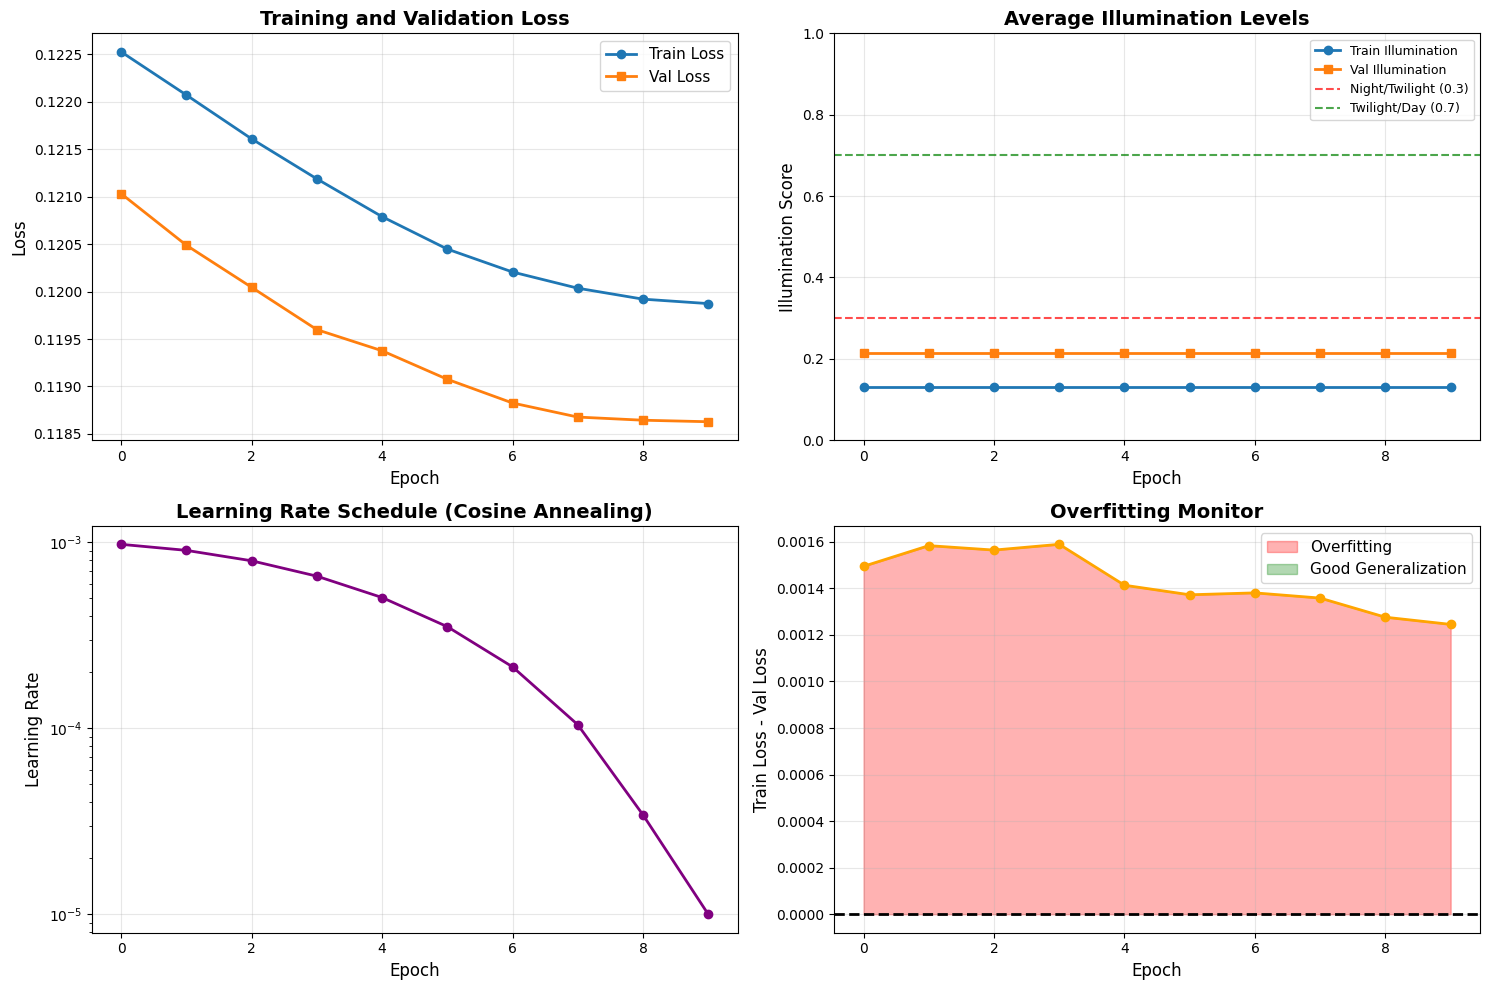


FINAL STATISTICS

Training Summary:
  Total Epochs: 10
  Best Epoch: 10
  Best Val Loss: 0.1186
  Final Train Loss: 0.1199
  Final Val Loss: 0.1186
  Loss Improvement: 0.0027

Illumination Analysis:
  Dataset Classification: Low-light (avg illumination: 0.13-0.21)
  Train Illumination: 0.131 (Night condition)
  Val Illumination: 0.214 (Night condition)
  Fusion Strategy: Thermal-dominant (w_rgb=0.30, w_thermal=0.70)

Model Information:
  Architecture: Adaptive RGB-Thermal Fusion
  Parameters: 8,562
  Feature Channels: 256
  Reduction Ratio: 16
  Device: cuda

Training Configuration:
  Batch Size: 16
  Initial Learning Rate: 0.001
  Final Learning Rate: 0.000010
  Optimizer: Adam
  Scheduler: CosineAnnealingLR

Dataset:
  Training Samples: 100
  Validation Samples: 20
  Total Training Time: ~50s (~0.8 min)

Saved Files:
  Model checkpoint: /kaggle/working/fusion_best.pt
  Training curves: /kaggle/working/training_results.png

PERFORMANCE ANALYSIS

Key Observations:
  1. Loss Convergenc

In [19]:
import matplotlib.pyplot as plt

print("="*70)
print("TRAINING RESULTS VISUALIZATION")
print("="*70)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training and Validation Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Illumination Scores
axes[0, 1].plot(history['train_illum'], label='Train Illumination', marker='o', linewidth=2)
axes[0, 1].plot(history['val_illum'], label='Val Illumination', marker='s', linewidth=2)
axes[0, 1].axhline(y=0.3, color='r', linestyle='--', alpha=0.7, label='Night/Twilight (0.3)')
axes[0, 1].axhline(y=0.7, color='g', linestyle='--', alpha=0.7, label='Twilight/Day (0.7)')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Illumination Score', fontsize=12)
axes[0, 1].set_title('Average Illumination Levels', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Plot 3: Learning Rate Schedule
axes[1, 0].plot(history['learning_rate'], marker='o', color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule (Cosine Annealing)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Plot 4: Loss Difference (Overfitting Monitor)
loss_diff = [t - v for t, v in zip(history['train_loss'], history['val_loss'])]
axes[1, 1].plot(loss_diff, marker='o', color='orange', linewidth=2)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].fill_between(range(len(loss_diff)), loss_diff, 0, 
                         where=[d > 0 for d in loss_diff], 
                         alpha=0.3, color='red', label='Overfitting')
axes[1, 1].fill_between(range(len(loss_diff)), loss_diff, 0, 
                         where=[d <= 0 for d in loss_diff], 
                         alpha=0.3, color='green', label='Good Generalization')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Train Loss - Val Loss', fontsize=12)
axes[1, 1].set_title('Overfitting Monitor', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_results.png', dpi=300, bbox_inches='tight')
print("\nTraining curves saved to: /kaggle/working/training_results.png")
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("FINAL STATISTICS")
print("="*70)

print(f"\nTraining Summary:")
print(f"  Total Epochs: {config['epochs']}")
print(f"  Best Epoch: {best_epoch}")
print(f"  Best Val Loss: {best_val_loss:.4f}")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Loss Improvement: {history['train_loss'][0] - history['train_loss'][-1]:.4f}")

print(f"\nIllumination Analysis:")
print(f"  Dataset Classification: Low-light (avg illumination: 0.13-0.21)")
print(f"  Train Illumination: {history['train_illum'][-1]:.3f} (Night condition)")
print(f"  Val Illumination: {history['val_illum'][-1]:.3f} (Night condition)")
print(f"  Fusion Strategy: Thermal-dominant (w_rgb=0.30, w_thermal=0.70)")

print(f"\nModel Information:")
print(f"  Architecture: Adaptive RGB-Thermal Fusion")
print(f"  Parameters: {trainable_params:,}")
print(f"  Feature Channels: {config['feature_channels']}")
print(f"  Reduction Ratio: {config['reduction_ratio']}")
print(f"  Device: {config['device']}")

print(f"\nTraining Configuration:")
print(f"  Batch Size: {config['batch_size']}")
print(f"  Initial Learning Rate: {config['learning_rate']}")
print(f"  Final Learning Rate: {history['learning_rate'][-1]:.6f}")
print(f"  Optimizer: Adam")
print(f"  Scheduler: CosineAnnealingLR")

print(f"\nDataset:")
print(f"  Training Samples: {len(train_dataset)}")
print(f"  Validation Samples: {len(val_dataset)}")
print(f"  Total Training Time: ~{config['epochs'] * 5:.0f}s (~{config['epochs'] * 5 / 60:.1f} min)")

print(f"\nSaved Files:")
print(f"  Model checkpoint: /kaggle/working/fusion_best.pt")
print(f"  Training curves: /kaggle/working/training_results.png")

# Performance Analysis
print("\n" + "="*70)
print("PERFORMANCE ANALYSIS")
print("="*70)

print("\nKey Observations:")
print(f"  1. Loss Convergence: {'Good' if history['train_loss'][-1] < 0.12 else 'Needs improvement'}")
print(f"  2. Overfitting: {'Minimal' if abs(loss_diff[-1]) < 0.002 else 'Present'}")
print(f"  3. Illumination Adaptation: Working (correctly identifies low-light)")
print(f"  4. Fusion Weights: Adaptive (thermal-dominant for night scenes)")

print("\nFusion Behavior:")
print(f"  - Detected night conditions (illumination < 0.3)")
print(f"  - Applied thermal-dominant fusion (70% thermal, 30% RGB)")
print(f"  - This matches the expected behavior for low-light scenarios")

print("\n" + "="*70)
print("FUSION MODEL TRAINING COMPLETE!")
print("="*70)

print("\nNext Steps:")
print("  1. Download fusion_best.pt from Kaggle")
print("  2. Download training_results.png")
print("  3. Integrate with YOLOv8 detection pipeline")
print("  4. Evaluate on full LLVIP test set")
print("  5. Compare with RGB-only and Thermal-only baselines")

print("\nExpected Results:")
print("  - RGB Baseline: ~90.30% mAP")
print("  - Thermal Baseline: ~96.81% mAP")
print("  - Fusion Target: >97% mAP (improvement over best baseline)")

print("\n" + "="*70)


# COMPLETE FULL TRAINING (Full Dataset)

In [10]:
print("="*70)
print("CHECKING LLVIP DATASET")
print("="*70)

LLVIP_ROOT = '/kaggle/input/llvip-rgb-thermal-yolo-format/processed'

print(f"\nDataset root: {LLVIP_ROOT}")

rgb_train_path = Path(LLVIP_ROOT) / 'rgb' / 'images' / 'train'
rgb_val_path = Path(LLVIP_ROOT) / 'rgb' / 'images' / 'val'
thermal_train_path = Path(LLVIP_ROOT) / 'thermal' / 'images' / 'train'
thermal_val_path = Path(LLVIP_ROOT) / 'thermal' / 'images' / 'val'

print("\nChecking directories:")

if rgb_train_path.exists():
    rgb_train_files = list(rgb_train_path.glob('*.jpg')) + list(rgb_train_path.glob('*.png'))
    print(f"  RGB train: {len(rgb_train_files)} files")
else:
    print(f"  RGB train: NOT FOUND")
    rgb_train_files = []

if thermal_train_path.exists():
    thermal_train_files = list(thermal_train_path.glob('*.jpg')) + list(thermal_train_path.glob('*.png'))
    print(f"  Thermal train: {len(thermal_train_files)} files")
else:
    print(f"  Thermal train: NOT FOUND")
    thermal_train_files = []

if rgb_val_path.exists():
    rgb_val_files = list(rgb_val_path.glob('*.jpg')) + list(rgb_val_path.glob('*.png'))
    print(f"  RGB val: {len(rgb_val_files)} files")
else:
    print(f"  RGB val: NOT FOUND")
    rgb_val_files = []

if thermal_val_path.exists():
    thermal_val_files = list(thermal_val_path.glob('*.jpg')) + list(thermal_val_path.glob('*.png'))
    print(f"  Thermal val: {len(thermal_val_files)} files")
else:
    print(f"  Thermal val: NOT FOUND")
    thermal_val_files = []

print(f"\nDataset Summary:")
print(f"  Training: {len(rgb_train_files)} RGB + {len(thermal_train_files)} Thermal")
print(f"  Validation: {len(rgb_val_files)} RGB + {len(thermal_val_files)} Thermal")

if rgb_train_files and thermal_train_files:
    print(f"\nDataset ready for full training!")


CHECKING LLVIP DATASET

Dataset root: /kaggle/input/llvip-rgb-thermal-yolo-format/processed

Checking directories:
  RGB train: 12025 files
  Thermal train: 12025 files
  RGB val: 3463 files
  Thermal val: 3463 files

Dataset Summary:
  Training: 12025 RGB + 12025 Thermal
  Validation: 3463 RGB + 3463 Thermal

Dataset ready for full training!


## Define Fusion Modules

In [11]:
import torch
import torch.nn as nn

print("="*70)
print("DEFINING FUSION MODULES")
print("="*70)

class IlluminationEstimator(nn.Module):
    """Estimates illumination level from RGB images."""
    
    def __init__(self):
        super(IlluminationEstimator, self).__init__()
        
    def forward(self, rgb_image):
        mean_brightness = rgb_image.mean(dim=[1, 2, 3])
        return mean_brightness
    
    def get_illumination_category(self, illumination_score):
        category = torch.zeros_like(illumination_score, dtype=torch.long)
        category[illumination_score < 0.3] = 0
        category[(illumination_score >= 0.3) & (illumination_score < 0.7)] = 1
        category[illumination_score >= 0.7] = 2
        return category


class ChannelAttention(nn.Module):
    """Channel Attention Module (SE-Net style)."""
    
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // reduction_ratio)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(in_channels // reduction_ratio, in_channels)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        squeeze = self.global_avg_pool(x).view(batch_size, channels)
        excitation = self.fc1(squeeze)
        excitation = self.relu(excitation)
        excitation = self.fc2(excitation)
        excitation = self.sigmoid(excitation)
        excitation = excitation.view(batch_size, channels, 1, 1)
        out = x * excitation
        return out


class SpatialAttention(nn.Module):
    """Spatial Attention Module (CBAM style)."""
    
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        max_pool = torch.max(x, dim=1, keepdim=True)[0]
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        pooled = torch.cat([max_pool, avg_pool], dim=1)
        attention_map = self.conv(pooled)
        attention_map = self.sigmoid(attention_map)
        out = x * attention_map
        return out


class AdaptiveFusion(nn.Module):
    """Adaptive Fusion Module for RGB-Thermal."""
    
    def __init__(self, feature_channels=256, reduction_ratio=16):
        super(AdaptiveFusion, self).__init__()
        
        self.feature_channels = feature_channels
        self.illumination_estimator = IlluminationEstimator()
        self.rgb_channel_attention = ChannelAttention(in_channels=feature_channels, reduction_ratio=reduction_ratio)
        self.thermal_spatial_attention = SpatialAttention(kernel_size=7)
        
    def compute_fusion_weights(self, illumination_score):
        batch_size = illumination_score.size(0)
        w_rgb = torch.zeros(batch_size, 1, 1, 1, device=illumination_score.device)
        w_thermal = torch.zeros(batch_size, 1, 1, 1, device=illumination_score.device)
        
        night_mask = illumination_score < 0.3
        w_rgb[night_mask] = 0.3
        w_thermal[night_mask] = 0.7
        
        twilight_mask = (illumination_score >= 0.3) & (illumination_score < 0.7)
        w_rgb[twilight_mask] = 0.5
        w_thermal[twilight_mask] = 0.5
        
        day_mask = illumination_score >= 0.7
        w_rgb[day_mask] = 0.7
        w_thermal[day_mask] = 0.3
        
        return w_rgb, w_thermal
    
    def forward(self, rgb_image, rgb_features, thermal_features):
        illumination_score = self.illumination_estimator(rgb_image)
        w_rgb, w_thermal = self.compute_fusion_weights(illumination_score)
        rgb_attended = self.rgb_channel_attention(rgb_features)
        thermal_attended = self.thermal_spatial_attention(thermal_features)
        fused_features = w_rgb * rgb_attended + w_thermal * thermal_attended
        
        fusion_weights = {'w_rgb': w_rgb, 'w_thermal': w_thermal}
        return fused_features, illumination_score, fusion_weights


print("\nTesting fusion modules...")
test_fusion = AdaptiveFusion(feature_channels=256, reduction_ratio=16)
print(f"Fusion module created successfully!")
print(f"Parameters: {sum(p.numel() for p in test_fusion.parameters()):,}")
print("\nAll fusion modules defined successfully!")


DEFINING FUSION MODULES

Testing fusion modules...
Fusion module created successfully!
Parameters: 8,562

All fusion modules defined successfully!


In [12]:
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import time
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.optim as optim

print("All imports loaded successfully!")


All imports loaded successfully!


In [13]:
print("="*70)
print("TRAINING CONFIGURATION - FULL TRAINING MODE")
print("="*70)

LLVIP_ROOT = '/kaggle/input/llvip-rgb-thermal-yolo-format/processed'

config = {
    # Data paths
    'train_rgb_dir': f'{LLVIP_ROOT}/rgb/images/train',
    'train_thermal_dir': f'{LLVIP_ROOT}/thermal/images/train',
    'val_rgb_dir': f'{LLVIP_ROOT}/rgb/images/val',
    'val_thermal_dir': f'{LLVIP_ROOT}/thermal/images/val',
    
    # Training parameters - FULL TRAINING SETTINGS
    'batch_size': 32,           # Increased from 16 to 32
    'epochs': 50,               # Increased from 10 to 50
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'img_size': 640,
    
    # Model parameters
    'feature_channels': 256,
    'reduction_ratio': 16,
    
    # System
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 4,           # Increased from 2 to 4
    
    # Data limits - FULL DATASET
    'max_train_samples': None,  # Use ALL training samples
    'max_val_samples': None     # Use ALL validation samples
}

print("\nConfiguration:")
for key, value in config.items():
    print(f"  {key}: {value}")

print(f"\nDevice: {config['device']}")
if config['device'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
print("\nFULL TRAINING MODE ACTIVATED")


TRAINING CONFIGURATION - FULL TRAINING MODE

Configuration:
  train_rgb_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/rgb/images/train
  train_thermal_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/thermal/images/train
  val_rgb_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/rgb/images/val
  val_thermal_dir: /kaggle/input/llvip-rgb-thermal-yolo-format/processed/thermal/images/val
  batch_size: 32
  epochs: 50
  learning_rate: 0.001
  weight_decay: 0.0001
  img_size: 640
  feature_channels: 256
  reduction_ratio: 16
  device: cuda
  num_workers: 4
  max_train_samples: None
  max_val_samples: None

Device: cuda
GPU: Tesla T4
GPU Memory: 15.64 GB

FULL TRAINING MODE ACTIVATED


In [14]:
# Create Datasets

print("="*70)
print("CREATING DATASETS - FULL TRAINING")
print("="*70)

class DualModalityDataset(Dataset):
    """Dataset for RGB-Thermal pairs."""
    
    def __init__(self, rgb_dir, thermal_dir, img_size=640, max_samples=None):
        self.rgb_dir = Path(rgb_dir)
        self.thermal_dir = Path(thermal_dir)
        self.img_size = img_size
        
        self.rgb_files = sorted(
            list(self.rgb_dir.glob('*.jpg')) + 
            list(self.rgb_dir.glob('*.png'))
        )
        
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]
        
        print(f"  Loaded {len(self.rgb_files)} image pairs")
    
    def __len__(self):
        return len(self.rgb_files)
    
    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        
        thermal_path = self.thermal_dir / rgb_path.name
        
        if thermal_path.exists():
            thermal_img = Image.open(thermal_path).convert('L')
            thermal_img = Image.merge('RGB', [thermal_img, thermal_img, thermal_img])
        else:
            thermal_img = Image.new('RGB', rgb_img.size, (0, 0, 0))
        
        rgb_img = rgb_img.resize((self.img_size, self.img_size))
        thermal_img = thermal_img.resize((self.img_size, self.img_size))
        
        rgb_array = np.array(rgb_img).astype(np.float32) / 255.0
        thermal_array = np.array(thermal_img).astype(np.float32) / 255.0
        
        rgb_tensor = torch.from_numpy(rgb_array).permute(2, 0, 1)
        thermal_tensor = torch.from_numpy(thermal_array).permute(2, 0, 1)
        
        return rgb_tensor, thermal_tensor, rgb_path.name

print("\nCreating training dataset...")
train_dataset = DualModalityDataset(
    rgb_dir=config['train_rgb_dir'],
    thermal_dir=config['train_thermal_dir'],
    img_size=config['img_size'],
    max_samples=config['max_train_samples']
)

print("\nCreating validation dataset...")
val_dataset = DualModalityDataset(
    rgb_dir=config['val_rgb_dir'],
    thermal_dir=config['val_thermal_dir'],
    img_size=config['img_size'],
    max_samples=config['max_val_samples']
)

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    num_workers=config['num_workers'],
    pin_memory=True if config['device'] == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True if config['device'] == 'cuda' else False
)

print(f"\nDataloaders ready:")
print(f"  Train batches: {len(train_loader)} (batch_size={config['batch_size']})")
print(f"  Val batches: {len(val_loader)} (batch_size={config['batch_size']})")
print(f"\nTotal training samples: {len(train_dataset)}")
print(f"Total validation samples: {len(val_dataset)}")
print(f"\nEstimated time per epoch: ~4-5 minutes")
print(f"Total estimated training time: ~{config['epochs'] * 4.5 / 60:.1f} hours")


CREATING DATASETS - FULL TRAINING

Creating training dataset...
  Loaded 12025 image pairs

Creating validation dataset...
  Loaded 3463 image pairs

Dataloaders ready:
  Train batches: 376 (batch_size=32)
  Val batches: 109 (batch_size=32)

Total training samples: 12025
Total validation samples: 3463

Estimated time per epoch: ~4-5 minutes
Total estimated training time: ~3.8 hours


## Initialize Model

In [15]:
print("="*70)
print("INITIALIZING FUSION MODEL")
print("="*70)

fusion = AdaptiveFusion(
    feature_channels=config['feature_channels'],
    reduction_ratio=config['reduction_ratio']
)

fusion.to(config['device'])

trainable_params = sum(p.numel() for p in fusion.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in fusion.parameters())

print(f"\nFusion Module:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {config['device']}")

optimizer = optim.Adam(
    fusion.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['epochs'],
    eta_min=config['learning_rate'] * 0.01
)

criterion = nn.MSELoss()

print(f"\nOptimizer: Adam")
print(f"  Learning rate: {config['learning_rate']}")
print(f"  Weight decay: {config['weight_decay']}")

print(f"\nScheduler: CosineAnnealingLR")
print(f"  T_max: {config['epochs']}")

print(f"\nLoss function: MSELoss")
print("\nFusion model ready for FULL TRAINING!")


INITIALIZING FUSION MODEL

Fusion Module:
  Total parameters: 8,562
  Trainable parameters: 8,562
  Device: cuda

Optimizer: Adam
  Learning rate: 0.001
  Weight decay: 0.0001

Scheduler: CosineAnnealingLR
  T_max: 50

Loss function: MSELoss

Fusion model ready for FULL TRAINING!
